# Batch Monitoring, Prediction, and Forecasting

`phibatch.monitor()` projects a batch (or partial batch) onto an MPCA/MPLS model and returns instantaneous T², SPE, and a complete-trajectory forecast.

`phibatch.predict()` gives end-of-batch quality predictions from a partial trajectory.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyphi.batch as phibatch
import pyphi.plots as pp
from bokeh.io import output_notebook
output_notebook(hide_banner=True)
import pyphi.plots as _ppmod
_ppmod.output_file = lambda *a, **kw: None
%matplotlib inline


Will be using the NEOS server in the absence of IPOPT and GAMS


## Prepare NOC Model (Film Coating)

In [2]:
bdata = pd.read_excel('../data/Batch Film Coating.xlsx')
samples_per_phase = {
    'STARTUP': 3, 'HEATING': 20, 'SPRAYING': 40,
    'DRYING': 40, 'DISCHARGING': 5
}
bdata_aligned = phibatch.phase_simple_align(bdata, samples_per_phase)
noc = bdata_aligned[~bdata_aligned.iloc[:, 0].isin(['B1905', 'B1805'])].copy()
dev = bdata_aligned[ bdata_aligned.iloc[:, 0].isin(['B1905', 'B1805'])].copy()

mpca_obj = phibatch.mpca(noc, 2, phase_samples=samples_per_phase)


phi.pca using NIPALS executed on: 2026-03-27 15:53:53.128773
# Iterations for PC #1:  17
# Iterations for PC #2:  40
--------------------------------------------------------------
PC #      Eig        R2X       sum(R2X) 
PC #1:    160.232    0.225     0.225
PC #2:    101.622    0.143     0.368
--------------------------------------------------------------


## Build Monitoring Confidence Intervals (Stage 1)

Call `monitor` with only training data (no `which_batch`) to build per-sample confidence intervals.

In [3]:
# Stage 1: build confidence intervals from NOC batches
phibatch.monitor(mpca_obj, noc)


Building real_time confidence intervals
Running batch: B211
Running batch: B311
Running batch: B411
Running batch: B1205


Running batch: B1810
Running batch: B1910
Running batch: B2010
Running batch: B2110


Running batch: B2210
Running batch: B2510
Running batch: B2705
Running batch: B2710


Running batch: B2805
Running batch: B2810
Running batch: B2910


Done


## Monitor All Normal Batches

Running batch: B211
Running batch: B311
Running batch: B411
Running batch: B1205


Running batch: B1810
Running batch: B1910
Running batch: B2010


Running batch: B2110
Running batch: B2210
Running batch: B2510
Running batch: B2705


Running batch: B2710
Running batch: B2805
Running batch: B2810
Running batch: B2910


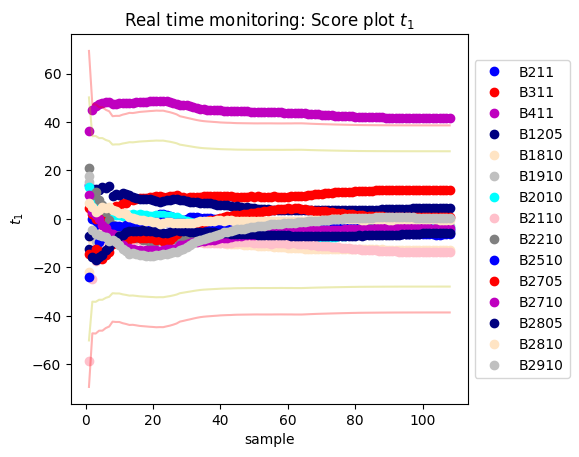

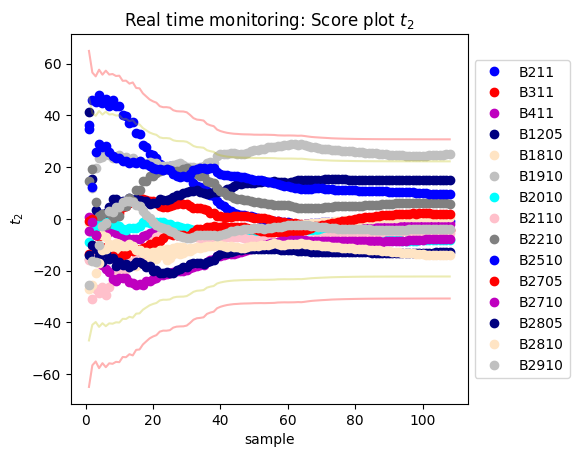

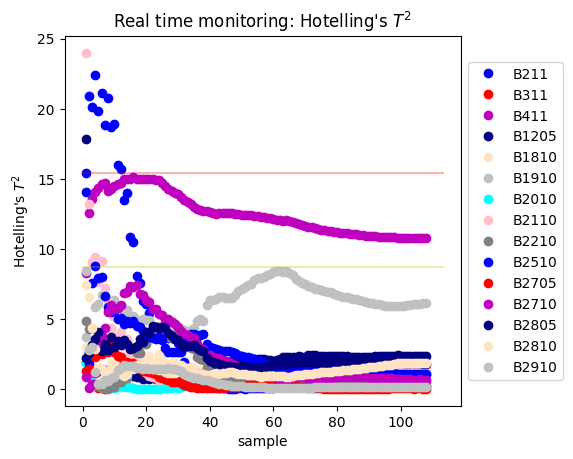

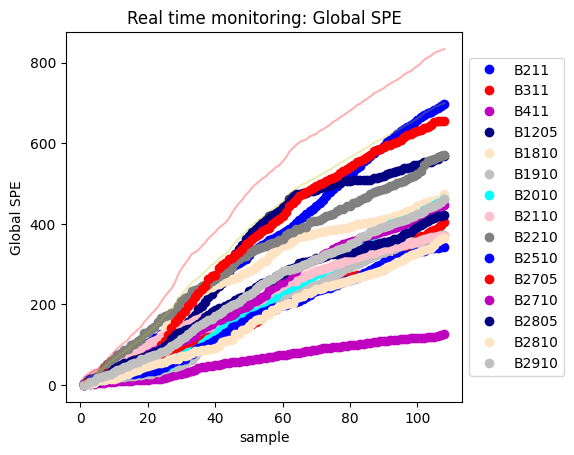

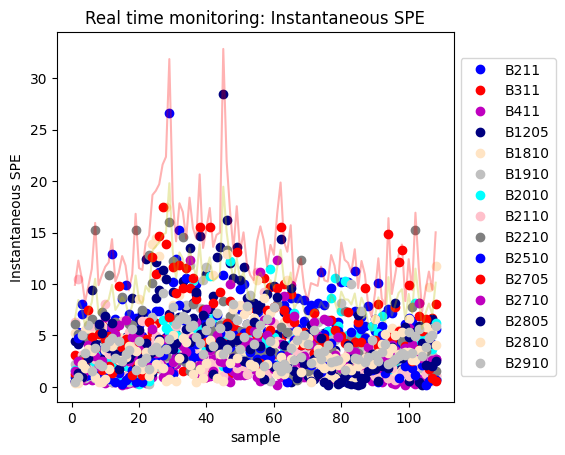

In [4]:
all_batches = noc.iloc[:, 0].unique().tolist()
mon_noc = phibatch.monitor(mpca_obj, noc, which_batch=all_batches)


## Monitor a Deviant Batch (B1905)

Running batch: B1905


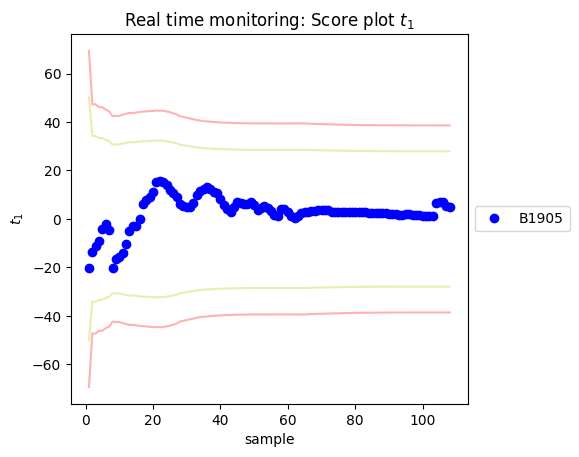

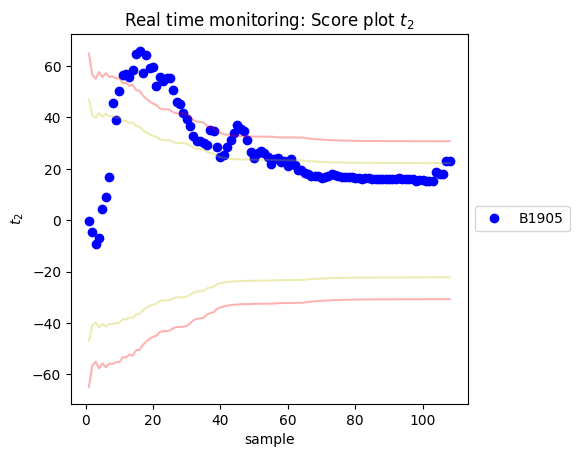

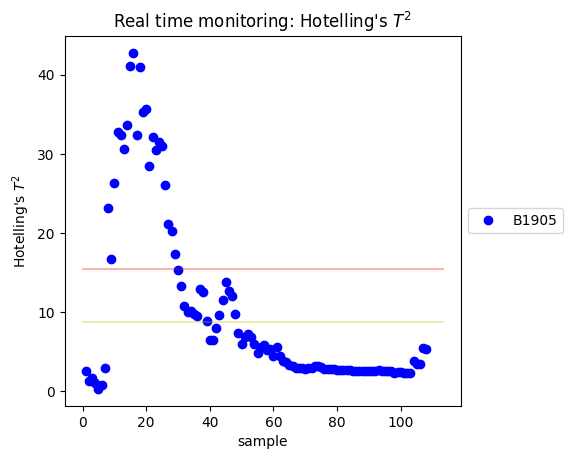

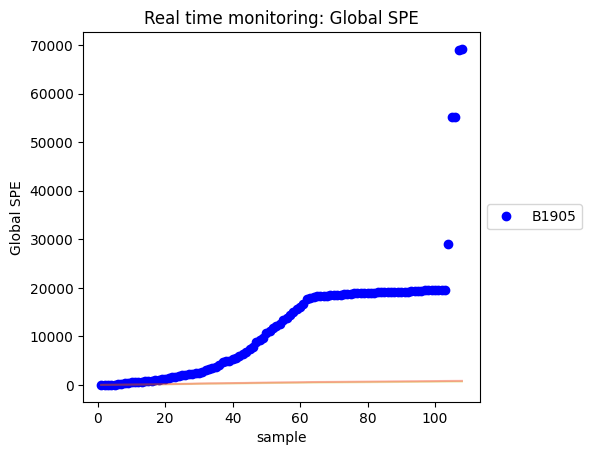

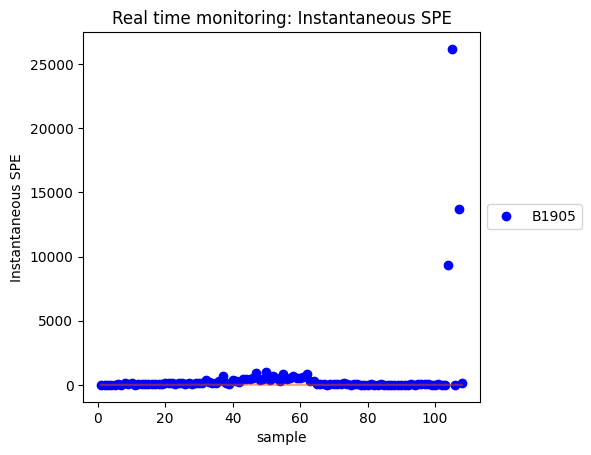

In [5]:
mon_dev = phibatch.monitor(mpca_obj, dev, which_batch=['B1905'])


## SPE Contributions at a Specific Sample

/tmp/ipykernel_3175170/1253031920.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(mon_dev['cont_spei'].columns, rotation=90)


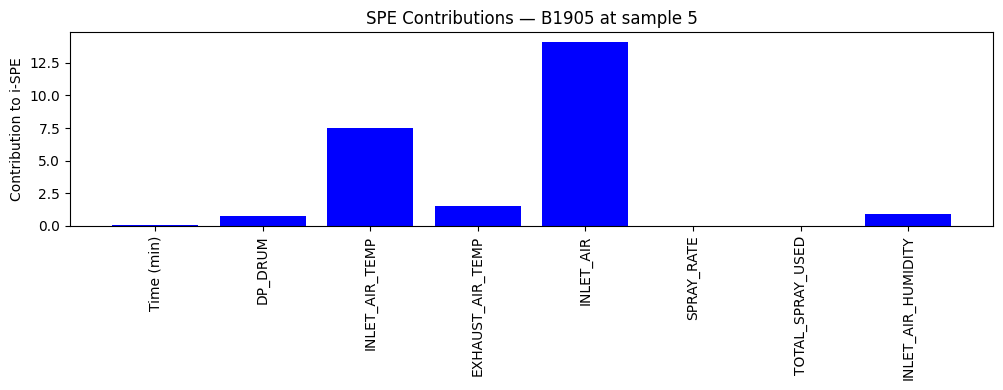

In [6]:
sam_num = 5
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(mon_dev['cont_spei'].columns, mon_dev['cont_spei'].iloc[sam_num - 1])
ax.set_xticklabels(mon_dev['cont_spei'].columns, rotation=90)
ax.set_ylabel('Contribution to i-SPE')
ax.set_title(f'SPE Contributions — B1905 at sample {sam_num}')
plt.tight_layout()
plt.show()


## SPE Contributions via `phibatch.contributions()`

`phibatch.contributions()` computes and plots variable contributions to SPE (or HT² / scores) for a named batch. Here we visualise the SPE contributions for the deviant batch **B1905**.

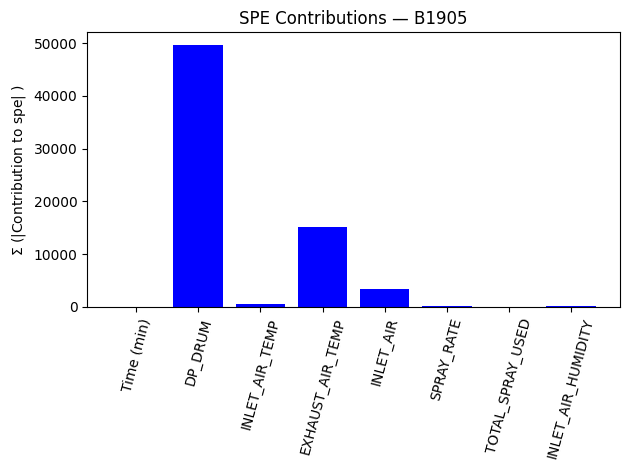

In [7]:
phibatch.contributions(
    mpca_obj,
    dev,
    'spe',
    to_obs=['B1905'],
    phase_samples=samples_per_phase,
    plot_title='SPE Contributions — B1905',
)

## Trajectory Forecasting

At any point in time, `monitor` returns a `'forecast'` key with predicted future trajectories based on the mean NOC trajectory.

Running batch: B2510


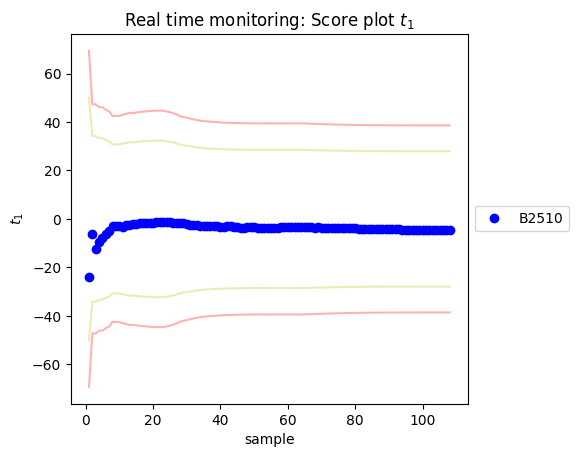

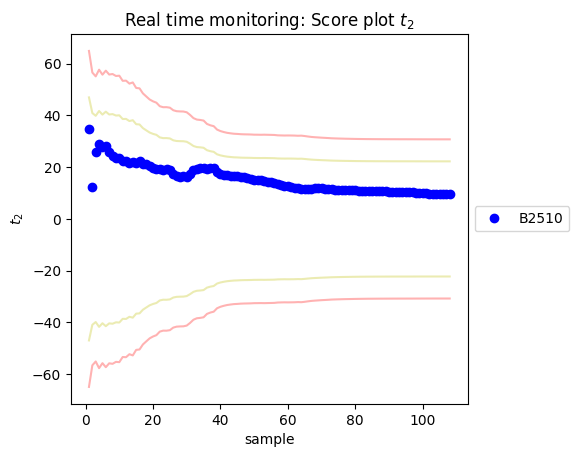

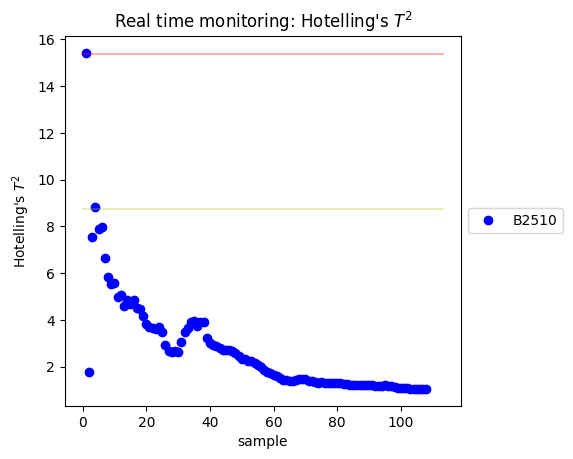

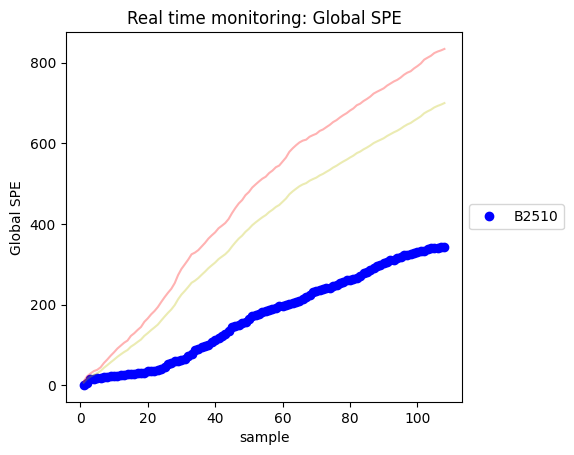

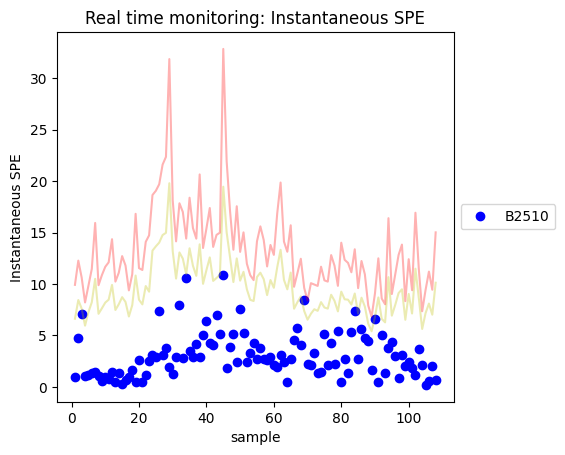

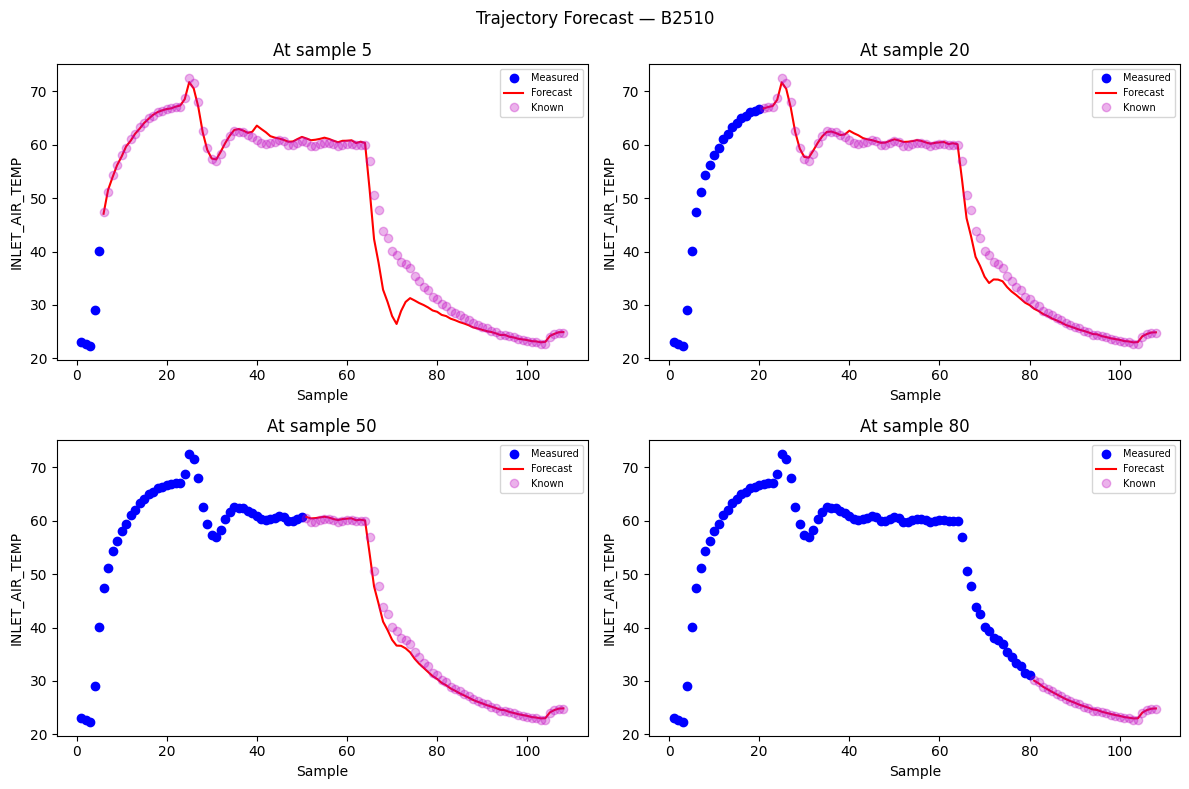

In [8]:
batch2forecast = 'B2510'
mon_fc = phibatch.monitor(mpca_obj, noc, which_batch=batch2forecast)
forecast = mon_fc['forecast']

var = 'INLET_AIR_TEMP'
mdata = noc[noc.iloc[:, 0] == batch2forecast]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, pit in zip(axes.ravel(), [5, 20, 50, 80]):
    f = forecast[pit - 1]
    x_obs  = np.arange(pit) + 1
    x_fore = np.arange(len(mdata)) + 1
    fore_vals = np.array([np.nan] * pit + f[var].values[pit:].tolist())
    ax.plot(x_obs, mdata[var].values[:pit], 'o', label='Measured')
    ax.plot(x_fore, fore_vals, '-', label='Forecast')
    ax.plot(np.arange(pit, len(mdata)) + 1, mdata[var].values[pit:],
            'o', alpha=0.3, label='Known')
    ax.set_title(f'At sample {pit}')
    ax.set_xlabel('Sample')
    ax.set_ylabel(var)
    ax.legend(fontsize=7)
plt.suptitle(f'Trajectory Forecast — {batch2forecast}')
plt.tight_layout()
plt.show()


## Batch Descriptors

`phibatch.descriptors()` extracts landmarks (min/max/mean of a variable within a phase) useful as features for end-of-batch models.

Note: `phase=` accepts a list of phase names.

In [9]:
desc = phibatch.descriptors(bdata_aligned, ['INLET_AIR_TEMP'],
                            ['min', 'max', 'mean'],
                            phase=['SPRAYING'])
print(desc.head())


  BATCH NUMBER  INLET_AIR_TEMP_SPRAYING_min  INLET_AIR_TEMP_SPRAYING_max  \
0         B211                    58.774635                    72.060030   
1         B311                    57.995789                    71.325030   
2         B411                    58.659251                    71.850020   
3        B1205                    58.066953                    70.665020   
4        B1805                    57.420020                    70.385799   

   INLET_AIR_TEMP_SPRAYING_mean  
0                     60.909803  
1                     60.685726  
2                     60.658678  
3                     62.128263  
4                     61.705139  


## MPLS End-of-Batch Quality Prediction (Dryer Dataset)

In [10]:
bdata_d = pd.read_excel('../data/Batch Dryer Case Study.xlsx', sheet_name='Trajectories')
cqa     = pd.read_excel('../data/Batch Dryer Case Study.xlsx', sheet_name='ProductQuality')
cat     = pd.read_excel('../data/Batch Dryer Case Study.xlsx', sheet_name='classifiers')
samples_d = {'Deagglomerate': 20, 'Heat': 30, 'Cooldown': 40}

bdata_d_aligned = phibatch.phase_simple_align(bdata_d, samples_d)
mpls_obj = phibatch.mpls(bdata_d_aligned, cqa, 3, phase_samples=samples_d)

pp.score_scatter(mpls_obj, [1, 2], CLASSID=cat, colorby='Quality')


phi.pls using NIPALS executed on: 2026-03-27 15:53:58.566819
# Iterations for LV #1:  32
# Iterations for LV #2:  35
# Iterations for LV #3:  21
--------------------------------------------------------------
LV #     Eig       R2X       sum(R2X)   R2Y       sum(R2Y)
LV #1:   86.793    0.122     0.122      0.229     0.229
LV #2:   133.694    0.160     0.281      0.071     0.300
LV #3:   51.590    0.067     0.349      0.109     0.409
--------------------------------------------------------------


## Monitor MPLS Model (Stage 1 + Stage 2)

Building real_time confidence intervals
Running batch: Batch 1
Running batch: Batch 2


Running batch: Batch 3
Running batch: Batch 4


Running batch: Batch 5
Running batch: Batch 6


Running batch: Batch 7
Running batch: Batch 8


Running batch: Batch 9
Running batch: Batch 10


...

Running batch: Batch 58
Running batch: Batch 59
Running batch: Batch 60
Running batch: Batch 61


Running batch: Batch 62
Running batch: Batch 63
Running batch: Batch 64
Running batch: Batch 65


Running batch: Batch 66
Running batch: Batch 67
Running batch: Batch 68


Running batch: Batch 69
Running batch: Batch 70
Running batch: Batch 71


Done
Running batch: Batch 5


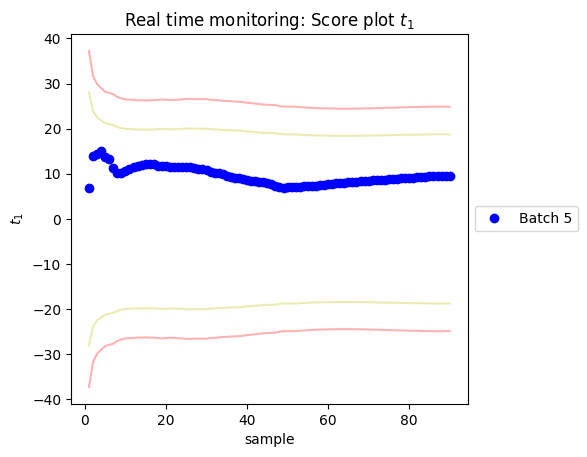

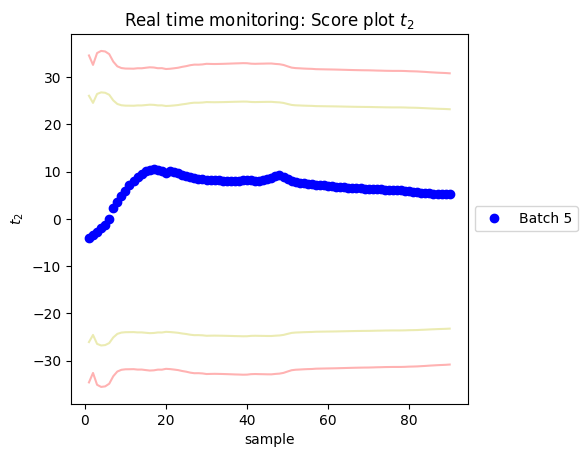

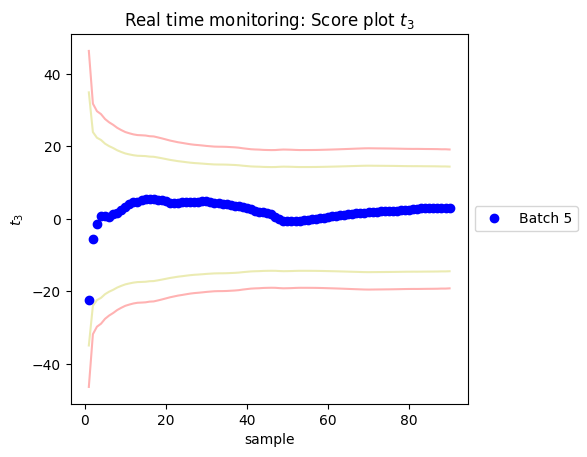

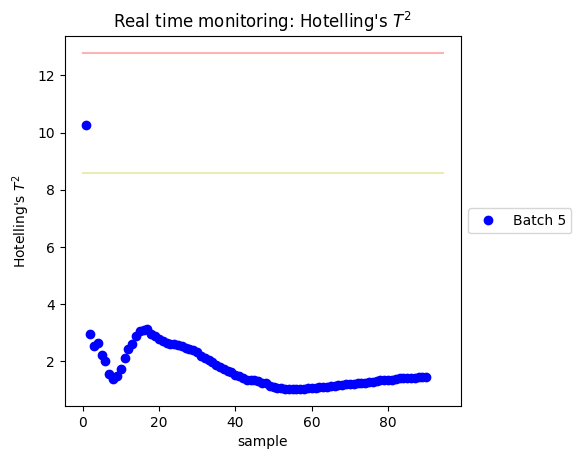

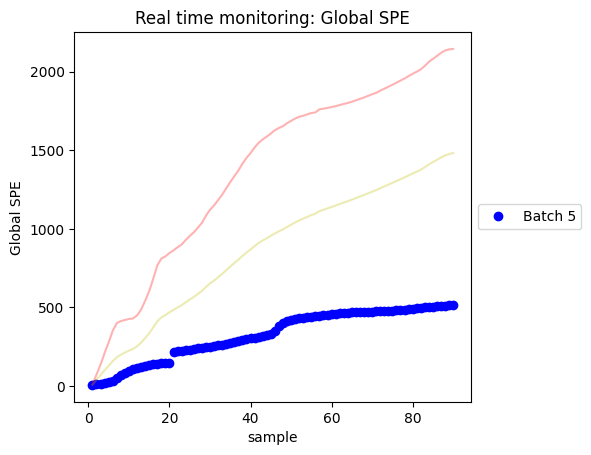

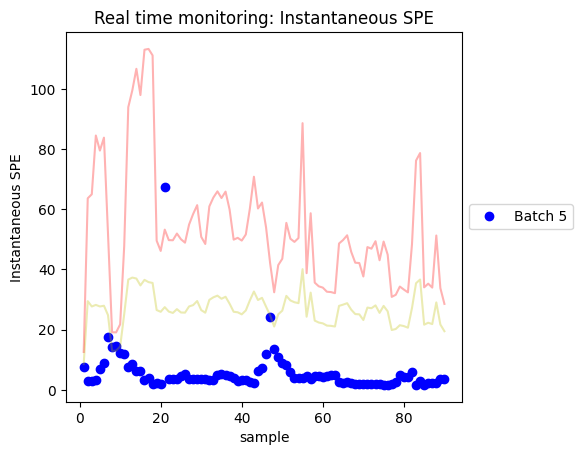

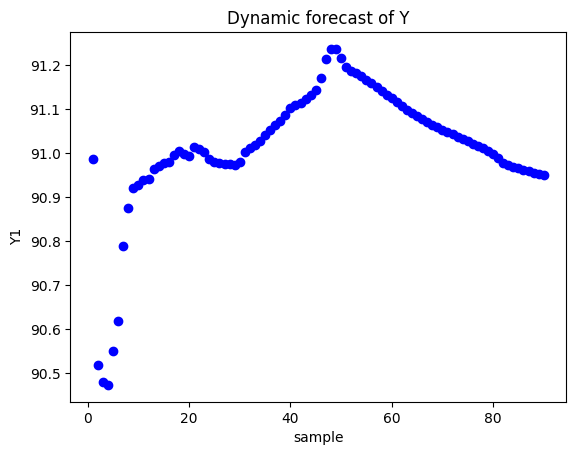

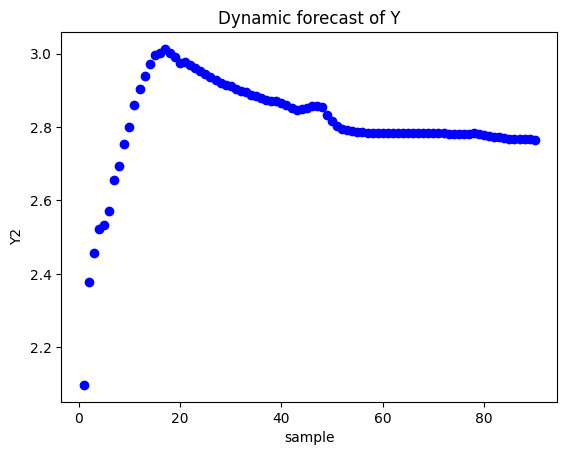

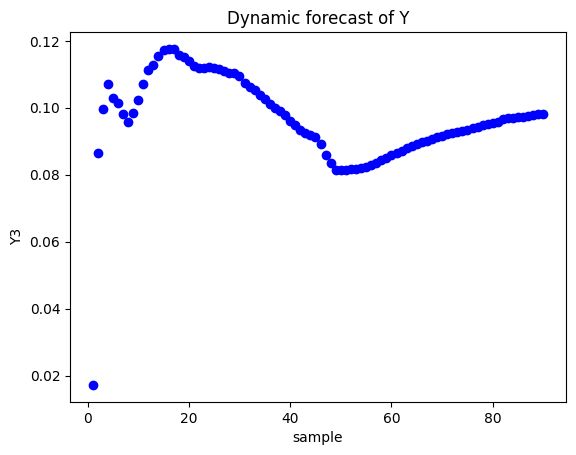

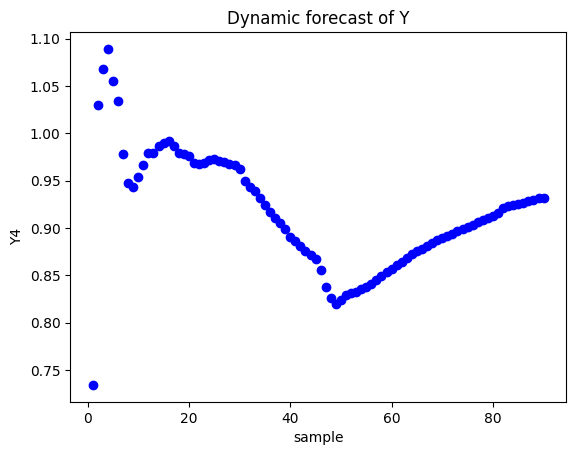

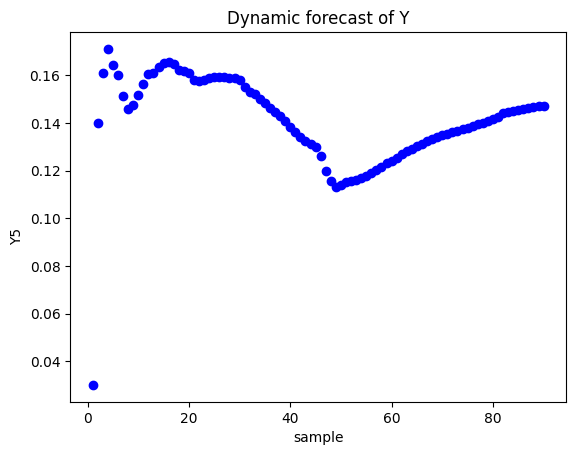

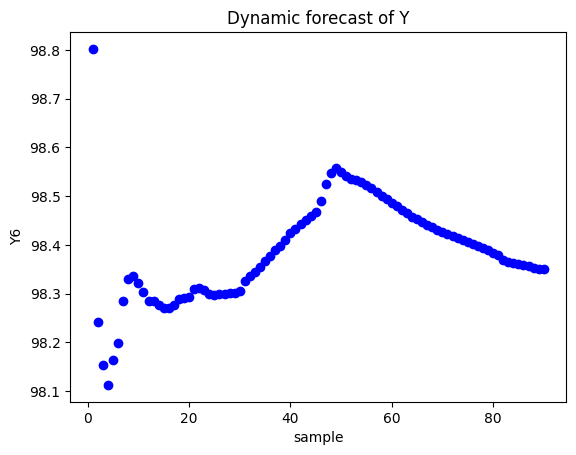

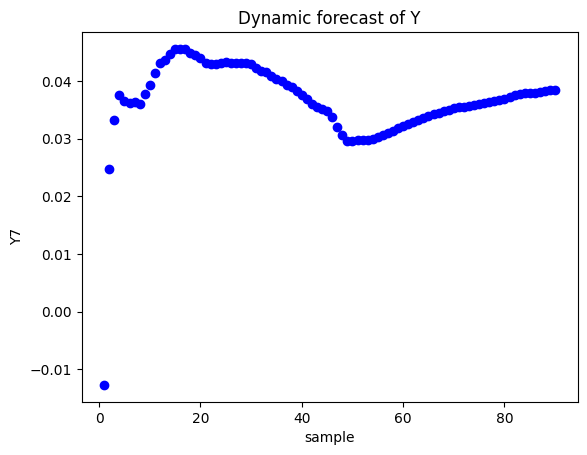

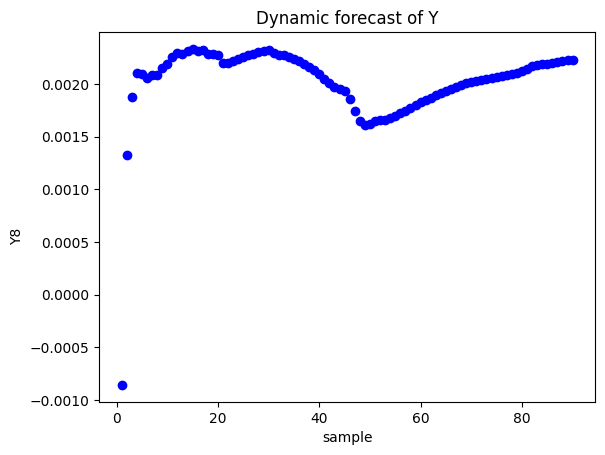

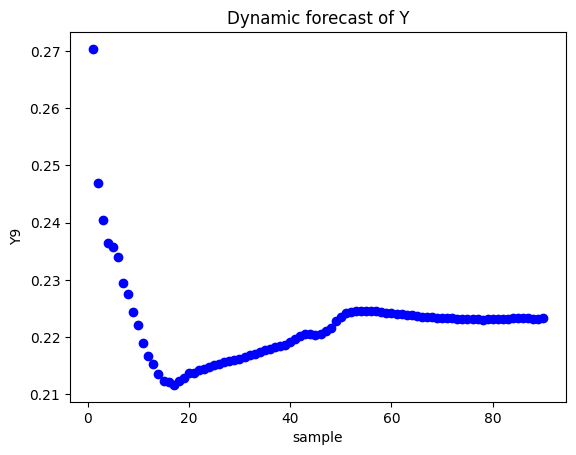

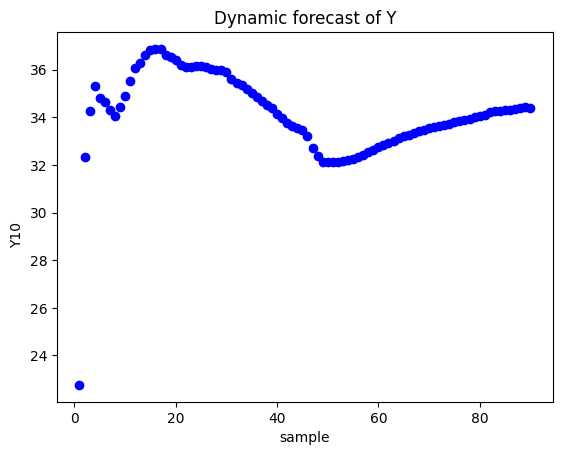

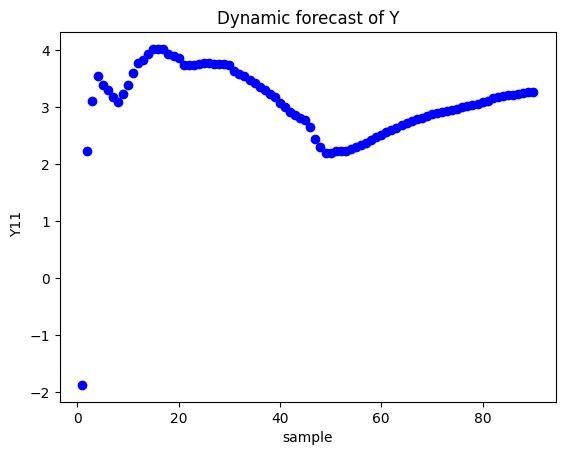

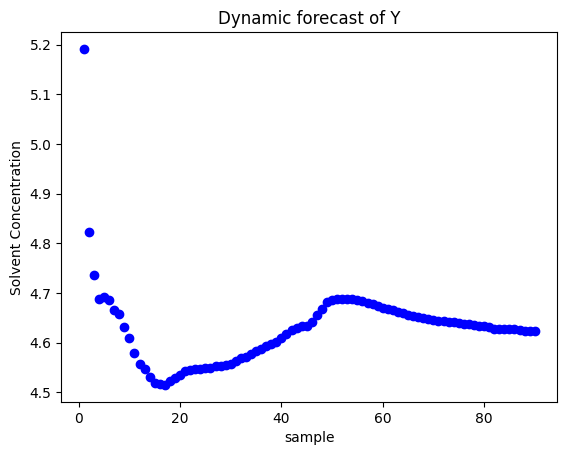

In [11]:
# Stage 1: build CI from all training batches
phibatch.monitor(mpls_obj, bdata_d_aligned)
# Stage 2: monitor a specific batch
mon_mpls = phibatch.monitor(mpls_obj, bdata_d_aligned, which_batch='Batch 5')


## End-of-Batch Quality Prediction with `phibatch.predict()`

`phibatch.predict()` unfolds the batch data, projects through the MPLS model, and returns predicted **Y** (end-of-batch quality) for every batch. Here we run it on the full Dryer dataset to get `Yhat` alongside the true values from the `cqa` sheet.

Predicted Y (end-of-batch quality):
Batch number  Y1           Y2           Y3           Y4           Y5           Y6           Y7           Y8           Y9           Y10            Y11     Solvent Concentration
     Batch 1    92.097248     3.118271     0.054519     0.483945     0.065669    99.026734     0.031153     0.002232     0.203781    29.414962  1.596358               4.595950
     Batch 2    91.801229     2.834222     0.028285     0.569639     0.009960    99.091308    -0.005232    -0.000935     0.235464    24.306820 -1.618237               4.973168
     Batch 3    91.492245     2.884763     0.062465     0.721697     0.072507    98.773863     0.016246     0.000552     0.225750    29.257335  0.718815               4.783159
     Batch 4    91.450878     2.978384     0.072968     0.771755     0.082953    98.709399     0.018862     0.000496     0.222071    30.500976  1.056097               4.744205
     Batch 5    90.952167     2.765353     0.097988     0.931304     0.147067    98.

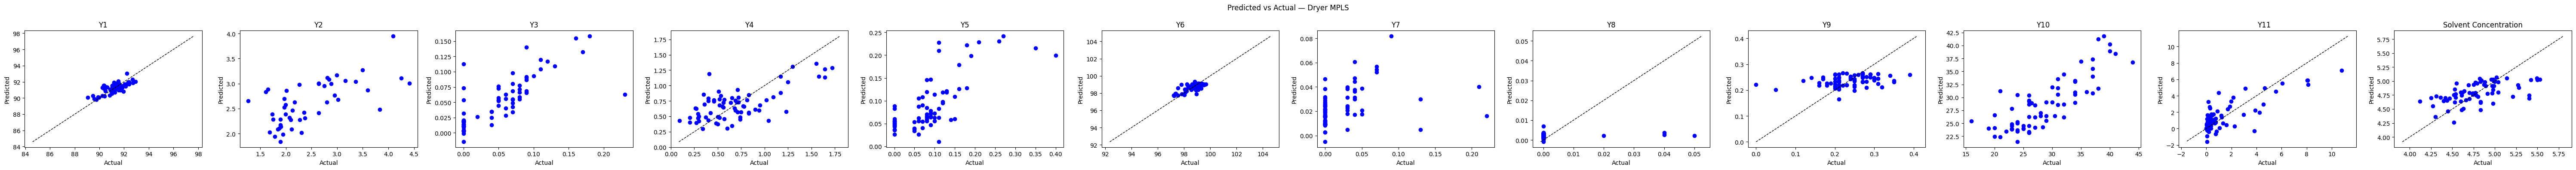

In [12]:
# Predict end-of-batch quality for all Dryer batches
pred_result = phibatch.predict(bdata_d_aligned, mpls_obj)
Yhat = pred_result['Yhat']
print('Predicted Y (end-of-batch quality):')
print(Yhat.to_string(index=False))

# Compare against true CQA values
print('\nTrue CQA values:')
print(cqa.to_string(index=False))

# Visual: predicted vs actual for each quality variable
fig, axes = plt.subplots(1, len(mpls_obj['varidY']), figsize=(5 * len(mpls_obj['varidY']), 4))
if len(mpls_obj['varidY']) == 1:
    axes = [axes]
batch_ids = Yhat.iloc[:, 0].values
for ax, yvar in zip(axes, mpls_obj['varidY']):
    y_true = cqa.set_index(cqa.columns[0]).loc[batch_ids, yvar].values
    y_pred = Yhat[yvar].values
    ax.scatter(y_true, y_pred)
    lims = [min(y_true.min(), y_pred.min()) * 0.95, max(y_true.max(), y_pred.max()) * 1.05]
    ax.plot(lims, lims, 'k--', lw=1)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(yvar)
plt.suptitle('Predicted vs Actual — Dryer MPLS')
plt.tight_layout()
plt.show()